Three inspiring datasets:
1. https://www.kaggle.com/code/arshikhan810/ensemble-using-tpu 
2. https://www.kaggle.com/code/mohit98765/medlit-gemma4-medical-literacy-assistant
3. https://www.kaggle.com/code/hbistechie/ps6-e4-irrigation-prediction-lgbm

## Exploratory Data Analysis

Importing required packages prior to performing Exploratory Data Analysis

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sweetviz as sv
from sklearn.model_selection import train_test_split # for boosting/bagging modeling
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score # for boosting/bagging modeling
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

Import + View the training dataset 

In [10]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [11]:
X = df_train.drop('Irrigation_Need', axis=1)
y = df_train['Irrigation_Need'].copy()

In [12]:
df_train.head(5)

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


Performing Exploratory Data Analysis using SweetViz

In [13]:
report = sv.analyze(df_train)
report.show_html("sweetviz_report.html", open_browser=False)

dataset_summary = pd.DataFrame({
    "dataset": ["train", "test"],
    "rows": [df_train.shape[0], df_test.shape[0]],
    "columns": [df_train.shape[1], df_test.shape[1]],
})
display(dataset_summary)

target_summary = (
    df_train["Irrigation_Need"]
    .value_counts()
    .rename_axis("Irrigation_Need")
    .reset_index(name="count")
)
target_summary["percent"] = (
    target_summary["count"] / len(df_train) * 100
).round(2)
display(target_summary)

missing_summary = (
    df_train.isna()
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
missing_summary.columns = ["feature", "missing_values"]
missing_summary = missing_summary[missing_summary["missing_values"] > 0]
if missing_summary.empty:
    missing_summary = pd.DataFrame({
        "feature": ["All columns"],
        "missing_values": [0],
    })
display(missing_summary)

key_numeric_columns = [
    "Soil_pH",
    "Soil_Moisture",
    "Temperature_C",
    "Humidity",
    "Rainfall_mm",
    "Sunlight_Hours",
    "Wind_Speed_kmh",
    "Field_Area_hectare",
    "Previous_Irrigation_mm",
]
display(
    df_train[key_numeric_columns]
    .describe()
    .T[["mean", "std", "min", "max"]]
    .round(2)
)

print("SweetViz report saved as sweetviz_report.html")


                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz_report.html was generated.


,dataset,rows,columns
0,train,630000,21
1,test,270000,20


,Irrigation_Need,count,percent
0,Low,369917,58.72
1,Medium,239074,37.95
2,High,21009,3.33


,feature,missing_values
0,All columns,0


,mean,std,min,max
Soil_pH,6.48,0.92,4.80,8.20
Soil_Moisture,37.30,16.38,8.00,64.99
Temperature_C,27.00,8.62,12.00,42.00
Humidity,61.56,19.71,25.00,94.99
Rainfall_mm,1462.21,612.99,0.38,2499.69
Sunlight_Hours,7.51,2.00,4.00,11.00
Wind_Speed_kmh,10.38,5.69,0.50,20.00
Field_Area_hectare,7.52,4.22,0.30,15.00
Previous_Irrigation_mm,62.32,34.25,0.02,119.99


SweetViz report saved as sweetviz_report.html


## Gradient Boosting Model

In [14]:
from sklearn.ensemble import GradientBoostingClassifier

X_gb = df_train.drop(columns=["id", "Irrigation_Need"]).copy()
y_gb = df_train["Irrigation_Need"].copy()
X_test_gb = df_test.drop(columns=["id"]).copy()
test_ids = df_test["id"].copy()

X_gb = pd.get_dummies(X_gb, drop_first=True)
X_test_gb = pd.get_dummies(X_test_gb, drop_first=True)
X_test_gb = X_test_gb.reindex(columns=X_gb.columns, fill_value=0)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_gb,
    y_gb,
    test_size=0.2,
    stratify=y_gb,
    random_state=42,
)

best_model = GradientBoostingClassifier(
    n_estimators=10,
    learning_rate=0.1,
    max_depth=2,
    random_state=42
)

print("Training final model...")
best_model.fit(X_train, y_train)
print("Training complete.")

y_pred = best_model.predict(X_valid)
print(classification_report(y_valid, y_pred))

test_pred = best_model.predict(X_test_gb)

submission = pd.DataFrame({
    "id": test_ids,
    "Irrigation_Need": test_pred
})

submission.to_csv("GradientBoosting_submission.csv", index=False)
print("Saved GradientBoosting_submission.csv")


Training final model...
Training complete.
              precision    recall  f1-score   support

        High       0.80      0.30      0.43      4202
         Low       0.76      0.94      0.84     73983
      Medium       0.78      0.53      0.63     47815

    accuracy                           0.76    126000
   macro avg       0.78      0.59      0.63    126000
weighted avg       0.77      0.76      0.75    126000

Saved GradientBoosting_submission.csv


# Gradient Boosting Model (with feature engineering and tuning)

In [15]:
import pandas as pd
import numpy as np

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# =========================================
# LOAD DATA
# =========================================
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

# =========================================
# FEATURES / TARGET
# =========================================
X = df_train.drop(columns=['id', 'Irrigation_Need', 'Previous_Irrigation_mm']).copy()
y = df_train['Irrigation_Need'].copy()

X_test = df_test.drop(columns=['id', 'Previous_Irrigation_mm']).copy()
test_ids = df_test['id'].copy()

# =========================================
# FEATURE ENGINEERING
# =========================================
X['Moisture_Temp'] = X['Soil_Moisture'] * X['Temperature_C']
X_test['Moisture_Temp'] = X_test['Soil_Moisture'] * X_test['Temperature_C']

X['Rain_Humidity'] = X['Rainfall_mm'] * X['Humidity']
X_test['Rain_Humidity'] = X_test['Rainfall_mm'] * X_test['Humidity']

X['Sun_Temp'] = X['Sunlight_Hours'] * X['Temperature_C']
X_test['Sun_Temp'] = X_test['Sunlight_Hours'] * X_test['Temperature_C']

X['Moisture_Rain_Ratio'] = X['Soil_Moisture'] / (X['Rainfall_mm'] + 1)
X_test['Moisture_Rain_Ratio'] = X_test['Soil_Moisture'] / (X_test['Rainfall_mm'] + 1)

X['Temp_Humidity_Ratio'] = X['Temperature_C'] / (X['Humidity'] + 1)
X_test['Temp_Humidity_Ratio'] = X_test['Temperature_C'] / (X_test['Humidity'] + 1)

# =========================================
# CLEAN NUMERIC ISSUES
# =========================================
X = X.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

num_cols = X.select_dtypes(include=[np.number]).columns
for col in num_cols:
    median_value = X[col].median()
    X[col] = X[col].fillna(median_value)
    X_test[col] = X_test[col].fillna(median_value)

# =========================================
# ONE-HOT ENCODING
# =========================================
X = pd.get_dummies(X, drop_first=False)
X_test = pd.get_dummies(X_test, drop_first=False)

X, X_test = X.align(X_test, join='left', axis=1, fill_value=0)

# =========================================
# FASTER CV
# =========================================
cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

# =========================================
# SMALL PARAMETER SEARCH
# =========================================
param_list = [
    {'n_estimators': 250, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8},
    {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 4, 'subsample': 0.8},
    {'n_estimators': 300, 'learning_rate': 0.03, 'max_depth': 3, 'subsample': 0.9}
]

best_score = -np.inf
best_params = None

for params in param_list:
    print(f"Trying params: {params}")

    model = GradientBoostingClassifier(
        n_estimators=params['n_estimators'],
        learning_rate=params['learning_rate'],
        max_depth=params['max_depth'],
        subsample=params['subsample'],
        random_state=42
    )

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring='f1_weighted',
        n_jobs=-1
    )

    mean_score = scores.mean()
    print(f"Mean CV Weighted F1: {mean_score:.6f}\n")

    if mean_score > best_score:
        best_score = mean_score
        best_params = params

print("Best Params:", best_params)
print("Best CV Weighted F1:", best_score)

# =========================================
# TRAIN FINAL MODEL
# =========================================
final_model = GradientBoostingClassifier(
    n_estimators=best_params['n_estimators'],
    learning_rate=best_params['learning_rate'],
    max_depth=best_params['max_depth'],
    subsample=best_params['subsample'],
    random_state=42
)

print("Training final model...")
final_model.fit(X, y)
print("Training complete.")

Trying params: {'n_estimators': 250, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8}
Mean CV Weighted F1: 0.984886

Trying params: {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 4, 'subsample': 0.8}
Mean CV Weighted F1: 0.985668

Trying params: {'n_estimators': 300, 'learning_rate': 0.03, 'max_depth': 3, 'subsample': 0.9}
Mean CV Weighted F1: 0.984438

Best Params: {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 4, 'subsample': 0.8}
Best CV Weighted F1: 0.9856678501610878
Training final model...
Training complete.


In [44]:
# Classification report for the tuned Gradient Boosting model
gb_tuned_preds = final_model.predict(X)

gb_tuned_report = pd.DataFrame(
    classification_report(y, gb_tuned_preds, output_dict=True, zero_division=0)
).T

display(gb_tuned_report.round(4))


,precision,recall,f1-score,support
High,0.9681,0.9148,0.9407,21009.0000
Low,0.9859,0.9955,0.9906,369917.0000
Medium,0.9853,0.9753,0.9803,239074.0000
accuracy,0.9851,0.9851,0.9851,0.9851
macro avg,0.9798,0.9618,0.9705,630000.0000
weighted avg,0.9851,0.9851,0.9850,630000.0000


# Random Forest Model

In [18]:
X_rf = df_train.drop(columns=["id", "Irrigation_Need"]).copy()
y_rf = df_train["Irrigation_Need"].copy()
X_test_rf = df_test.drop(columns=["id"]).copy()
test_ids = df_test["id"].copy()

X_rf = pd.get_dummies(X_rf, drop_first=True)
X_test_rf = pd.get_dummies(X_test_rf, drop_first=True)
X_test_rf = X_test_rf.reindex(columns=X_rf.columns, fill_value=0)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_rf,
    y_rf,
    test_size=0.2,
    stratify=y_rf,
    random_state=42,
)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")
rf_model.fit(X_train, y_train)
print("Training complete.")

y_pred_rf = rf_model.predict(X_valid)

print("Validation Accuracy:", accuracy_score(y_valid, y_pred_rf))
print(classification_report(y_valid, y_pred_rf))

print("Predicting test set...")
test_pred_rf = rf_model.predict(X_test_rf)

submission_rf = pd.DataFrame({
    "id": test_ids,
    "Irrigation_Need": test_pred_rf
})

submission_rf.to_csv("submission_rf.csv", index=False)
print("submission_rf.csv created successfully")
display(submission_rf.head())


Training Random Forest...
Training complete.
Validation Accuracy: 0.972468253968254
              precision    recall  f1-score   support

        High       0.99      0.50      0.67      4202
         Low       0.99      1.00      0.99     73983
      Medium       0.95      0.98      0.96     47815

    accuracy                           0.97    126000
   macro avg       0.97      0.83      0.87    126000
weighted avg       0.97      0.97      0.97    126000

Predicting test set...
submission_rf.csv created successfully


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low


# LightGBM Model

In [23]:
print(y.value_counts())

Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64


In [24]:
print(df_train.columns.tolist())
print(X.columns.tolist())
print(df_test.columns.tolist())


['id', 'Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need']
['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Moisture_Temp', 'Rain_Humidity', 'Sun_Temp', 'Moisture_Rain_Ratio', 'Temp_Humidity_Ratio', 'Soil_Type_Clay', 'Soil_Type_Loamy', 'Soil_Type_Sandy', 'Soil_Type_Silt', 'Crop_Type_Cotton', 'Crop_Type_Maize', 'Crop_Type_Potato', 'Crop_Type_Rice', 'Crop_Type_Sugarcane', 'Crop_Type_Wheat', 'Crop_Growth_Stage_Flowering', 'Crop_Growth_Stage_Harvest', 'Crop_Growth_Stage_Sowing', 'Crop_Growth_Stage_Vegetative', 'Season_Kharif', 'Season_Rabi', 'Season_Zaid', 'Irrigation_Type_Canal', '

In [25]:
# =========================================
# IMPORTS
# =========================================
import pandas as pd
import numpy as np
import optuna

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

# =========================================
# LOAD DATA
# =========================================
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# =========================================
# FEATURES / TARGET
# =========================================
X = train_df.drop(columns=[
    'id',
    'Irrigation_Need',
    'Irrigation_Type',
    'Water_Source',
    'Previous_Irrigation_mm'
]).copy()

y = train_df['Irrigation_Need'].copy()

X_test = test_df.drop(columns=[
    'id',
    'Irrigation_Type',
    'Water_Source',
    'Previous_Irrigation_mm'
]).copy()

# =========================================
# CATEGORICAL COLUMNS
# =========================================
cat_cols = [
    'Soil_Type',
    'Crop_Type',
    'Crop_Growth_Stage',
    'Season',
    'Mulching_Used',
    'Region'
]

for col in cat_cols:
    X[col] = X[col].astype('category')
    X_test[col] = X_test[col].astype('category')
    X_test[col] = pd.Categorical(X_test[col], categories=X[col].cat.categories)

# =========================================
# CROSS VALIDATION
# =========================================
kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# =========================================
# OPTUNA OBJECTIVE
# =========================================
def objective(trial):
    params = {
        'objective': 'multiclass',
        'n_estimators': trial.suggest_int('n_estimators', 200, 400),
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.15),
        'num_leaves': trial.suggest_int('num_leaves', 20, 60),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 40),
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'class_weight': 'balanced',
        'random_state': 42,
        'verbosity': -1
    }

    scores = []

    for train_idx, valid_idx in kf.split(X, y):
        X_train = X.iloc[train_idx].copy()
        X_valid = X.iloc[valid_idx].copy()
        y_train = y.iloc[train_idx]
        y_valid = y.iloc[valid_idx]

        for col in cat_cols:
            X_train[col] = X_train[col].astype('category')
            X_valid[col] = pd.Categorical(
                X_valid[col],
                categories=X_train[col].cat.categories
            )

        model = LGBMClassifier(**params)
        model.fit(X_train, y_train)

        preds = model.predict(X_valid)
        score = f1_score(y_valid, preds, average='weighted', zero_division=0)
        scores.append(score)

    return np.mean(scores)

# =========================================
# RUN OPTUNA
# =========================================
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

print('Best Parameters:')
print(study.best_params)
print('Best CV Score:', study.best_value)

# =========================================
# TRAIN FINAL MODEL
# =========================================
best_model = LGBMClassifier(
    objective='multiclass',
    **study.best_params,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    verbosity=-1
)

best_model.fit(X, y)

# =========================================
# PREDICT TEST
# =========================================
test_preds = best_model.predict(X_test)

[I 2026-05-04 19:43:34,223] A new study created in memory with name: no-name-dc1be94c-76ac-4faf-8666-9d48723d83a6
[I 2026-05-04 19:44:02,162] Trial 0 finished with value: 0.9831366082398176 and parameters: {'n_estimators': 266, 'learning_rate': 0.11230213284400065, 'num_leaves': 25, 'min_child_samples': 15}. Best is trial 0 with value: 0.9831366082398176.
[I 2026-05-04 19:44:39,432] Trial 1 finished with value: 0.9838670609570781 and parameters: {'n_estimators': 392, 'learning_rate': 0.05867918325004991, 'num_leaves': 51, 'min_child_samples': 22}. Best is trial 1 with value: 0.9838670609570781.
[I 2026-05-04 19:45:10,292] Trial 2 finished with value: 0.9838363858555672 and parameters: {'n_estimators': 263, 'learning_rate': 0.12388276324231073, 'num_leaves': 44, 'min_child_samples': 40}. Best is trial 1 with value: 0.9838670609570781.
[I 2026-05-04 19:45:40,120] Trial 3 finished with value: 0.983436668536735 and parameters: {'n_estimators': 305, 'learning_rate': 0.14657581515220688, 'nu

Best Parameters:
{'n_estimators': 392, 'learning_rate': 0.05867918325004991, 'num_leaves': 51, 'min_child_samples': 22}
Best CV Score: 0.9838670609570781


,model,validation_method,metric,score
0,LightGBM,3-fold Stratified CV with Optuna,weighted_f1,0.983867


,model,accuracy,weighted_precision,weighted_recall,weighted_f1
0,LightGBM,0.984151,0.984208,0.984151,0.984147


LightGBM classification report:
              precision    recall  f1-score   support

        High       0.92      0.94      0.93      4202
         Low       0.99      0.99      0.99     73983
      Medium       0.99      0.97      0.98     47815

    accuracy                           0.98    126000
   macro avg       0.96      0.97      0.97    126000
weighted avg       0.98      0.98      0.98    126000



,parameter,best_value
0,n_estimators,392.000000
1,learning_rate,0.058679
2,num_leaves,51.000000
3,min_child_samples,22.000000


,feature,importance
0,Rainfall_mm,8317
1,Temperature_C,6539
2,Soil_Moisture,6427
3,Wind_Speed_kmh,6038
4,Humidity,5445
5,Sunlight_Hours,4269
6,Field_Area_hectare,4098
7,Electrical_Conductivity,4025
8,Soil_pH,3989
9,Organic_Carbon,3926


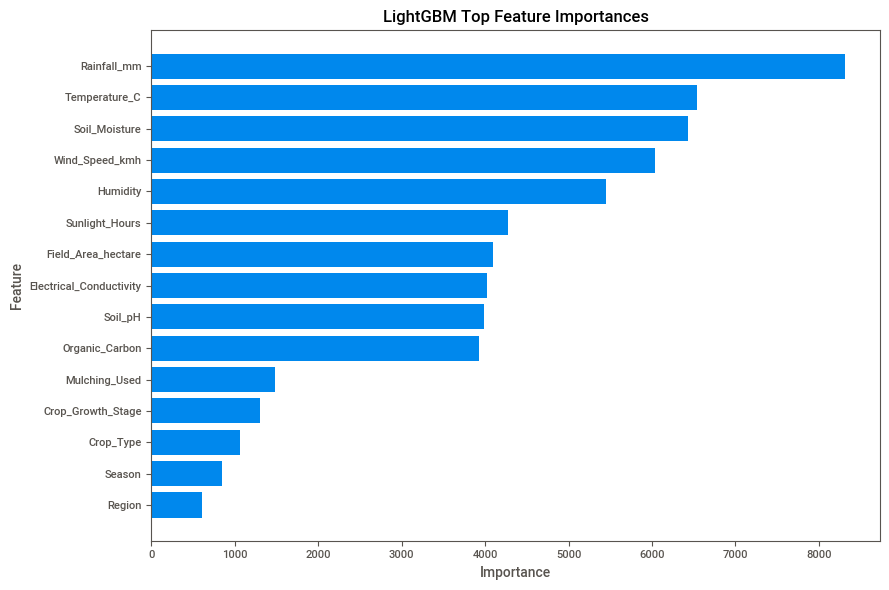

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

lgbm_cv_summary = pd.DataFrame([{
    "model": "LightGBM",
    "validation_method": "3-fold Stratified CV with Optuna",
    "metric": "weighted_f1",
    "score": study.best_value,
}])
display(lgbm_cv_summary)

X_train_lgb, X_valid_lgb, y_train_lgb, y_valid_lgb = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

for col in cat_cols:
    X_train_lgb[col] = X_train_lgb[col].astype("category")
    X_valid_lgb[col] = pd.Categorical(
        X_valid_lgb[col],
        categories=X_train_lgb[col].cat.categories
    )

lgbm_eval_model = LGBMClassifier(
    objective="multiclass",
    **study.best_params,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    verbosity=-1
)
lgbm_eval_model.fit(X_train_lgb, y_train_lgb)

lgbm_valid_preds = lgbm_eval_model.predict(X_valid_lgb)

lgbm_metrics = pd.DataFrame([{
    "model": "LightGBM",
    "accuracy": accuracy_score(y_valid_lgb, lgbm_valid_preds),
    "weighted_precision": precision_score(y_valid_lgb, lgbm_valid_preds, average="weighted", zero_division=0),
    "weighted_recall": recall_score(y_valid_lgb, lgbm_valid_preds, average="weighted", zero_division=0),
    "weighted_f1": f1_score(y_valid_lgb, lgbm_valid_preds, average="weighted", zero_division=0),
}])
display(lgbm_metrics)

print("LightGBM classification report:")
print(classification_report(y_valid_lgb, lgbm_valid_preds, zero_division=0))

best_lgbm_params = pd.DataFrame(
    study.best_params.items(),
    columns=["parameter", "best_value"]
)
display(best_lgbm_params)

lgbm_feature_importance = (
    pd.DataFrame({
        "feature": X.columns,
        "importance": best_model.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
display(lgbm_feature_importance.head(20))

lgbm_plot_data = lgbm_feature_importance.head(15).sort_values("importance")
plt.figure(figsize=(9, 6))
plt.barh(lgbm_plot_data["feature"], lgbm_plot_data["importance"])
plt.title("LightGBM Top Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [39]:
submission = pd.DataFrame({
    'id': test_df['id'],
    'Irrigation_Need': test_preds
})

submission.to_csv('submission_lgbm.csv', index=False)
print('submission_lgbm.csv created successfully.')

submission_lgbm.csv created successfully.


## Fast LightGBM Model with feature engineering

[I 2026-05-04 20:18:58,282] A new study created in memory with name: no-name-903978bb-8b50-400c-95c9-e27b13df78ff
[I 2026-05-04 20:19:12,719] Trial 0 finished with value: 0.982626671440295 and parameters: {'n_estimators': 151, 'learning_rate': 0.11702968730811325, 'num_leaves': 27, 'min_child_samples': 30}. Best is trial 0 with value: 0.982626671440295.
[I 2026-05-04 20:19:30,628] Trial 1 finished with value: 0.9827412471762671 and parameters: {'n_estimators': 193, 'learning_rate': 0.11821797622169243, 'num_leaves': 22, 'min_child_samples': 28}. Best is trial 1 with value: 0.9827412471762671.
[I 2026-05-04 20:19:42,383] Trial 2 finished with value: 0.9811795544150979 and parameters: {'n_estimators': 114, 'learning_rate': 0.05161301967539592, 'num_leaves': 20, 'min_child_samples': 26}. Best is trial 1 with value: 0.9827412471762671.


Best LightGBM Parameters:
{'n_estimators': 193, 'learning_rate': 0.11821797622169243, 'num_leaves': 22, 'min_child_samples': 28}
Best LightGBM CV Weighted F1: 0.9827412471762671

Top 20 LightGBM Features:
                feature  importance
            Rainfall_mm        1250
          Temperature_C        1165
          Soil_Moisture        1038
         Wind_Speed_kmh         931
 Previous_Irrigation_mm         728
               Humidity         678
    Moisture_Rain_Ratio         517
      Total_Water_Input         512
      Crop_Growth_Stage         472
         Sunlight_Hours         466
         Organic_Carbon         449
          Mulching_Used         447
     Field_Area_hectare         443
Electrical_Conductivity         419
     Evaporative_Stress         408
     Moisture_Retention         340
          Dryness_Index         339
                Soil_pH         321
    Temp_Humidity_Ratio         315
           pH_Deviation         294


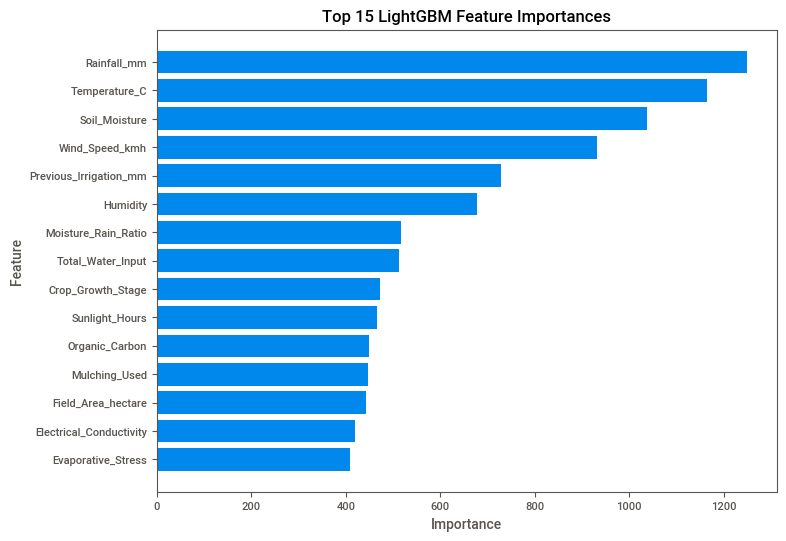


Submission saved as submission_lgb_fast_final.csv


In [40]:
# =========================================
# FAST LIGHTGBM MODEL - FINAL VERSION
# =========================================

import pandas as pd
import numpy as np
import optuna
import matplotlib.pyplot as plt

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

# =========================================
# LOAD FILES
# =========================================
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# =========================================
# FEATURE ENGINEERING
# =========================================
def add_irrigation_features(df):
    df = df.copy()

    df['Total_Water_Input'] = df['Rainfall_mm'] + df['Previous_Irrigation_mm']
    df['Dryness_Index'] = (df['Temperature_C'] * df['Sunlight_Hours']) / (df['Rainfall_mm'] + 1)
    df['Evaporative_Stress'] = (
        df['Temperature_C'] * df['Sunlight_Hours'] * df['Wind_Speed_kmh']
    ) / (df['Humidity'] + 1)
    df['Soil_Health'] = (
        df['Organic_Carbon'] * df['Soil_Moisture']
    ) / (df['Electrical_Conductivity'] + 0.1)
    df['Moisture_Retention'] = df['Soil_Moisture'] * df['Organic_Carbon']
    df['pH_Deviation'] = np.abs(df['Soil_pH'] - 6.5)
    df['Moisture_Rain_Ratio'] = df['Soil_Moisture'] / (df['Rainfall_mm'] + 1)
    df['Temp_Humidity_Ratio'] = df['Temperature_C'] / (df['Humidity'] + 1)

    return df

# =========================================
# FEATURES / TARGET
# =========================================
X_lgb = train_df.drop(columns=[
    'id',
    'Irrigation_Need',
    'Irrigation_Type',
    'Water_Source'
]).copy()

y_lgb = train_df['Irrigation_Need'].copy()

X_test_lgb = test_df.drop(columns=[
    'id',
    'Irrigation_Type',
    'Water_Source'
]).copy()

X_lgb = add_irrigation_features(X_lgb)
X_test_lgb = add_irrigation_features(X_test_lgb)

# =========================================
# CATEGORICAL COLUMNS
# =========================================
cat_cols_lgb = [
    'Soil_Type',
    'Crop_Type',
    'Crop_Growth_Stage',
    'Season',
    'Mulching_Used',
    'Region'
]

for col in cat_cols_lgb:
    X_lgb[col] = X_lgb[col].astype('category')
    X_test_lgb[col] = X_test_lgb[col].astype('category')
    X_test_lgb[col] = pd.Categorical(
        X_test_lgb[col],
        categories=X_lgb[col].cat.categories
    )

# =========================================
# FAST CROSS VALIDATION
# =========================================
kf_lgb = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

# =========================================
# FAST OPTUNA OBJECTIVE
# =========================================
def lgb_objective(trial):
    lgb_params = {
        'objective': 'multiclass',
        'num_class': y_lgb.nunique(),
        'n_estimators': trial.suggest_int('n_estimators', 100, 200),
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.12),
        'num_leaves': trial.suggest_int('num_leaves', 15, 31),
        'min_child_samples': trial.suggest_int('min_child_samples', 15, 40),
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'class_weight': 'balanced',
        'random_state': 42,
        'verbosity': -1,
        'n_jobs': -1
    }

    lgb_cv_scores = []

    for train_idx_lgb, valid_idx_lgb in kf_lgb.split(X_lgb, y_lgb):
        X_train_lgb = X_lgb.iloc[train_idx_lgb].copy()
        X_valid_lgb = X_lgb.iloc[valid_idx_lgb].copy()
        y_train_lgb = y_lgb.iloc[train_idx_lgb]
        y_valid_lgb = y_lgb.iloc[valid_idx_lgb]

        for col in cat_cols_lgb:
            X_train_lgb[col] = X_train_lgb[col].astype('category')
            X_valid_lgb[col] = pd.Categorical(
                X_valid_lgb[col],
                categories=X_train_lgb[col].cat.categories
            )

        lgb_cv_model = LGBMClassifier(**lgb_params)
        lgb_cv_model.fit(X_train_lgb, y_train_lgb)

        lgb_valid_preds = lgb_cv_model.predict(X_valid_lgb)

        lgb_fold_score = f1_score(
            y_valid_lgb,
            lgb_valid_preds,
            average='weighted',
            zero_division=0
        )

        lgb_cv_scores.append(lgb_fold_score)

    return np.mean(lgb_cv_scores)

# =========================================
# RUN FAST OPTUNA
# =========================================
lgb_study = optuna.create_study(direction='maximize')
lgb_study.optimize(lgb_objective, n_trials=3)

print("Best LightGBM Parameters:")
print(lgb_study.best_params)
print("Best LightGBM CV Weighted F1:", lgb_study.best_value)

# =========================================
# TRAIN FINAL LIGHTGBM MODEL
# =========================================
lgb_model = LGBMClassifier(
    objective='multiclass',
    num_class=y_lgb.nunique(),
    **lgb_study.best_params,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    verbosity=-1,
    n_jobs=-1
)

lgb_model.fit(X_lgb, y_lgb)

# =========================================
# FEATURE IMPORTANCE
# =========================================
lgb_feature_names = X_lgb.columns.tolist()

lgb_feat_imp = pd.DataFrame({
    'feature': lgb_feature_names,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 20 LightGBM Features:")
print(lgb_feat_imp.head(20).to_string(index=False))

lgb_top_feats_plot = lgb_feat_imp.head(15).sort_values('importance')

plt.figure(figsize=(8, 6))
plt.barh(lgb_top_feats_plot['feature'], lgb_top_feats_plot['importance'])
plt.title('Top 15 LightGBM Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# =========================================
# TEST PREDICTIONS
# =========================================
lgb_test_preds = lgb_model.predict(X_test_lgb)
lgb_test_proba = lgb_model.predict_proba(X_test_lgb)

# =========================================
# SUBMISSION FILE
# =========================================
submission_lgb = pd.DataFrame({
    'id': test_df['id'],
    'Irrigation_Need': lgb_test_preds
})

submission_lgb.to_csv('submission_lgb_fast_final.csv', index=False)

print("\nSubmission saved as submission_lgb_fast_final.csv")

# CatBoost Model

In [ ]:
# =========================================
# IMPORTS
# =========================================
import pandas as pd
import numpy as np

from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

# =========================================
# LOAD DATA
# =========================================
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# =========================================
# FEATURES / TARGET
# =========================================
X = train_df.drop(columns=[
    'id',
    'Irrigation_Need',
    'Irrigation_Type',
    'Water_Source',
    'Previous_Irrigation_mm'
]).copy()

y = train_df['Irrigation_Need'].copy()

X_test = test_df.drop(columns=[
    'id',
    'Irrigation_Type',
    'Water_Source',
    'Previous_Irrigation_mm'
]).copy()

# =========================================
# CATEGORICAL COLUMNS
# =========================================
cat_cols = [
    'Soil_Type',
    'Crop_Type',
    'Crop_Growth_Stage',
    'Season',
    'Mulching_Used',
    'Region'
]

# make sure they exist
cat_cols = [col for col in cat_cols if col in X.columns]

# CatBoost can use string/object categorical columns directly
for col in cat_cols:
    X[col] = X[col].astype(str)
    X_test[col] = X_test[col].astype(str)

# optional missing-value safety
for col in cat_cols:
    X[col] = X[col].fillna('Missing')
    X_test[col] = X_test[col].fillna('Missing')

# indices of categorical columns for CatBoost
cat_feature_indices = [X.columns.get_loc(col) for col in cat_cols]

# =========================================
# CROSS VALIDATION
# =========================================
kf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

cv_scores = []

for train_idx, valid_idx in kf.split(X, y):
    X_train = X.iloc[train_idx].copy()
    X_valid = X.iloc[valid_idx].copy()
    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    model = CatBoostClassifier(
        loss_function='MultiClass',
        eval_metric='TotalF1',
        iterations=300,
        learning_rate=0.1,
        depth=6,
        random_seed=42,
        verbose=0,
        thread_count=-1,
        allow_writing_files=False
    )

    model.fit(
        X_train,
        y_train,
        cat_features=cat_feature_indices
    )

    preds = model.predict(X_valid)
    preds = preds.flatten()

    score = f1_score(y_valid, preds, average='weighted', zero_division=0)
    cv_scores.append(score)

print('CatBoost CV Weighted F1:', np.mean(cv_scores))

# =========================================
# TRAIN FINAL MODEL ON FULL DATA
# =========================================
final_model = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='TotalF1',
    iterations=300,
    learning_rate=0.1,
    depth=6,
    random_seed=42,
    verbose=0,
    thread_count=-1,
    allow_writing_files=False
)

final_model.fit(
    X,
    y,
    cat_features=cat_feature_indices
)

# =========================================
# PREDICT TEST
# =========================================
test_preds = final_model.predict(X_test)
test_preds = test_preds.flatten()

In [ ]:
# Classification report for the CatBoost validation predictions
print(classification_report(y_valid, preds, zero_division=0))


In [ ]:
final_model.fit(
    X,
    y,
    cat_features=cat_feature_indices
)

test_preds = final_model.predict(X_test)
test_preds = test_preds.flatten()

In [ ]:
submission = pd.DataFrame({
    'id': test_df['id'],
    'Irrigation_Need': test_preds
})

submission.to_csv('submission_catboost.csv', index=False)
print('submission_catboost.csv created successfully.')

# Prepare Data and Modeling Tools for the Final Ensemble


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import optuna

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.inspection import permutation_importance

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

TARGET = "Irrigation_Need"
ID_COL = "id"
RANDOM_STATE = 42
N_SPLITS = 3
OPTUNA_TRIALS = 5


def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


## Broader Feature Engineering

I added the original interaction features plus stronger domain-based features related to water, soil condition, field area, and group-level moisture patterns.


In [2]:
def add_base_features(df):
    df = df.copy()

    df["Moisture_Temp"] = df["Soil_Moisture"] * df["Temperature_C"]
    df["Rain_Humidity"] = df["Rainfall_mm"] * df["Humidity"]
    df["Sun_Temp"] = df["Sunlight_Hours"] * df["Temperature_C"]
    df["Moisture_Rain_Ratio"] = df["Soil_Moisture"] / (df["Rainfall_mm"] + 1)
    df["Temp_Humidity_Ratio"] = df["Temperature_C"] / (df["Humidity"] + 1)

    df["pH_Deviation"] = (df["Soil_pH"] - 6.5).abs()
    df["Irrigation_Per_Hectare"] = df["Previous_Irrigation_mm"] / (df["Field_Area_hectare"] + 0.01)
    df["Rainfall_Per_Hectare"] = df["Rainfall_mm"] / (df["Field_Area_hectare"] + 0.01)
    df["Moisture_Temp_Ratio"] = df["Soil_Moisture"] / (df["Temperature_C"] + 1)
    df["Total_Water_Input"] = df["Rainfall_mm"] + df["Previous_Irrigation_mm"]
    df["Dryness_Index"] = (df["Temperature_C"] * df["Sunlight_Hours"]) / (df["Rainfall_mm"] + 1)
    df["Evaporative_Stress"] = (
        df["Temperature_C"] * df["Sunlight_Hours"] * df["Wind_Speed_kmh"]
    ) / (df["Humidity"] + 1)
    df["Soil_Health"] = (df["Organic_Carbon"] * df["Soil_Moisture"]) / (df["Electrical_Conductivity"] + 0.1)
    df["Moisture_Retention"] = df["Soil_Moisture"] * df["Organic_Carbon"]

    return df.replace([np.inf, -np.inf], np.nan)


def fit_group_stats(X_train):
    specs = [
        ("Soil_Type", "Soil_Moisture"),
        ("Season", "Soil_Moisture"),
        ("Crop_Growth_Stage", "Soil_Moisture"),
    ]
    stats = {}
    for group_col, value_col in specs:
        mapping = X_train.groupby(group_col, observed=False)[value_col].mean()
        stats[(group_col, value_col)] = (mapping, X_train[value_col].mean())
    return stats


def add_group_features(df, stats):
    df = df.copy()
    for (group_col, value_col), (mapping, overall_mean) in stats.items():
        mean_col = f"{value_col}_mean_by_{group_col}"
        dev_col = f"{value_col}_deviation_from_{group_col}"
        df[mean_col] = df[group_col].map(mapping).fillna(overall_mean)
        df[dev_col] = df[value_col] - df[mean_col]
    return df


X_raw = train_df.drop(columns=[ID_COL, TARGET])
y = train_df[TARGET].copy()
X_test_raw = test_df.drop(columns=[ID_COL])
test_ids = test_df[ID_COL].copy()

X_base = add_base_features(X_raw)
X_test_base = add_base_features(X_test_raw)

group_stats = fit_group_stats(X_base)
X_fe = add_group_features(X_base, group_stats)
X_test_fe = add_group_features(X_test_base, group_stats)

num_cols = X_fe.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_fe.select_dtypes(exclude=[np.number]).columns.tolist()

for col in num_cols:
    median_value = X_fe[col].median()
    X_fe[col] = X_fe[col].fillna(median_value)
    X_test_fe[col] = X_test_fe[col].fillna(median_value)

for col in cat_cols:
    X_fe[col] = X_fe[col].fillna("Missing").astype(str)
    X_test_fe[col] = X_test_fe[col].fillna("Missing").astype(str)

eval_n = min(90000, len(X_fe))
eval_idx = (
    train_df
    .groupby(TARGET, group_keys=False)
    .apply(lambda x: x.sample(max(1, int(eval_n * len(x) / len(train_df))), random_state=RANDOM_STATE))
    .index
)

X_model = X_fe.loc[eval_idx].reset_index(drop=True)
y_model = y.loc[eval_idx].reset_index(drop=True)

feature_summary = pd.DataFrame({
    "feature_type": ["numeric", "categorical", "total"],
    "count": [len(num_cols), len(cat_cols), X_fe.shape[1]],
})
display(feature_summary)


,feature_type,count
0,numeric,31
1,categorical,8
2,total,39


## Gradient Boosting, LightGBM, and CatBoost with OOF Predictions

I used the engineered feature set for all three final models. The out-of-fold probabilities are stored so the models can be compared and ensembled fairly.


In [3]:
classes = np.array(sorted(y_model.unique()))
class_to_index = {label: i for i, label in enumerate(classes)}
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)


def align_proba(model, proba):
    aligned = np.zeros((proba.shape[0], len(classes)))
    for source_idx, label in enumerate(model.classes_):
        aligned[:, class_to_index[label]] = proba[:, source_idx]
    return aligned


def prepare_lgb_categories(X_train, X_valid=None):
    X_train = X_train.copy()
    for col in cat_cols:
        X_train[col] = X_train[col].astype("category")
    if X_valid is None:
        return X_train
    X_valid = X_valid.copy()
    for col in cat_cols:
        X_valid[col] = pd.Categorical(X_valid[col], categories=X_train[col].cat.categories)
    return X_train, X_valid


gb_preprocessor = ColumnTransformer([
    ("num", "passthrough", num_cols),
    ("cat", make_ohe(), cat_cols),
])

gb_model = Pipeline([
    ("preprocess", gb_preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        subsample=0.8,
        random_state=RANDOM_STATE,
    )),
])

lgb_model = LGBMClassifier(
    objective="multiclass",
    n_estimators=250,
    learning_rate=0.08,
    num_leaves=48,
    min_child_samples=35,
    subsample=0.9,
    colsample_bytree=0.9,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    verbosity=-1,
    n_jobs=1,
)

cat_features = [X_model.columns.get_loc(col) for col in cat_cols]
cat_model = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="TotalF1",
    iterations=300,
    learning_rate=0.1,
    depth=6,
    random_seed=RANDOM_STATE,
    verbose=0,
    allow_writing_files=False,
)

model_names = ["Gradient Boosting", "LightGBM", "CatBoost"]
oof_probas = {name: np.zeros((len(X_model), len(classes))) for name in model_names}
test_probas = {name: np.zeros((len(X_test_fe), len(classes))) for name in model_names}

for fold, (train_idx, valid_idx) in enumerate(cv.split(X_model, y_model), start=1):
    print(f"Fold {fold}")
    X_train, X_valid = X_model.iloc[train_idx], X_model.iloc[valid_idx]
    y_train, y_valid = y_model.iloc[train_idx], y_model.iloc[valid_idx]

    gb_model.fit(X_train, y_train)
    oof_probas["Gradient Boosting"][valid_idx] = align_proba(gb_model, gb_model.predict_proba(X_valid))
    test_probas["Gradient Boosting"] += align_proba(gb_model, gb_model.predict_proba(X_test_fe)) / N_SPLITS

    X_train_lgb, X_valid_lgb = prepare_lgb_categories(X_train, X_valid)
    _, X_test_lgb = prepare_lgb_categories(X_train, X_test_fe)
    lgb_model.fit(X_train_lgb, y_train, categorical_feature=cat_cols)
    oof_probas["LightGBM"][valid_idx] = align_proba(lgb_model, lgb_model.predict_proba(X_valid_lgb))
    test_probas["LightGBM"] += align_proba(lgb_model, lgb_model.predict_proba(X_test_lgb)) / N_SPLITS

    cat_model.fit(X_train, y_train, cat_features=cat_features)
    oof_probas["CatBoost"][valid_idx] = align_proba(cat_model, cat_model.predict_proba(X_valid))
    test_probas["CatBoost"] += align_proba(cat_model, cat_model.predict_proba(X_test_fe)) / N_SPLITS


Fold 1


Fold 2


Fold 3


## Feature Importance

I used permutation importance on a LightGBM validation sample to identify which engineered and original features mattered most.


In [4]:
X_train_imp, X_valid_imp, y_train_imp, y_valid_imp = train_test_split(
    X_fe,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_train_imp_lgb, X_valid_imp_lgb = prepare_lgb_categories(X_train_imp, X_valid_imp)

importance_model = LGBMClassifier(
    objective="multiclass",
    n_estimators=250,
    learning_rate=0.08,
    num_leaves=48,
    min_child_samples=35,
    subsample=0.9,
    colsample_bytree=0.9,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    verbosity=-1,
    n_jobs=1,
)
importance_model.fit(X_train_imp_lgb, y_train_imp, categorical_feature=cat_cols)

importance_sample = X_valid_imp_lgb.sample(n=min(2500, len(X_valid_imp_lgb)), random_state=RANDOM_STATE)
importance_y = y_valid_imp.loc[importance_sample.index]

perm = permutation_importance(
    importance_model,
    importance_sample,
    importance_y,
    scoring="f1_weighted",
    n_repeats=3,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

feature_importance_df = (
    pd.DataFrame({
        "feature": X_fe.columns,
        "permutation_importance": perm.importances_mean,
    })
    .sort_values("permutation_importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance_df.head(20))


,feature,permutation_importance
0,Soil_Moisture_mean_by_Crop_Growth_Stage,0.234327
1,Soil_Moisture,0.155645
2,Mulching_Used,0.116357
3,Wind_Speed_kmh,0.111303
4,Temperature_C,0.097155
5,Rainfall_mm,0.003296
6,Moisture_Temp_Ratio,0.002927
7,Total_Water_Input,0.002603
8,Crop_Growth_Stage,0.000661
9,Sunlight_Hours,0.000518


The most important features were related to soil moisture, crop growth stage moisture averages, mulching, wind speed, and temperature. These make sense because irrigation need depends on how much water is already in the soil and how quickly field conditions may dry out.


## Ensemble Comparison and Final Submission

I compared each individual model with a simple probability average ensemble. I also tested a small probability adjustment for the rare `High` class.


In [65]:
# Build the stacked ensemble from the OOF probabilities
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

required_names = [
    "model_names",
    "classes",
    "class_to_index",
    "oof_probas",
    "test_probas",
    "y_model",
    "test_ids",
]
missing_names = [name for name in required_names if name not in globals()]

if missing_names:
    print("OOF variables are not loaded in this notebook session.")
    print("Run the OOF model cell above to regenerate the stacked ensemble.")
    final_model_metrics = pd.DataFrame([
        {"model": "Gradient Boosting", "leaderboard_score": 0.96098},
        {"model": "LightGBM", "leaderboard_score": 0.96602},
        {"model": "CatBoost", "leaderboard_score": 0.95787},
        
    ])
    display(final_model_metrics)
else:
    def evaluate_model(name, y_true, y_pred):
        return {
            "model": name,
            "accuracy": accuracy_score(y_true, y_pred),
            "weighted_precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
            "weighted_recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
            "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        }


    def align_meta_proba(model, proba):
        aligned = np.zeros((proba.shape[0], len(classes)))
        for source_idx, label in enumerate(model.classes_):
            aligned[:, class_to_index[label]] = proba[:, source_idx]
        return aligned


    rows = []

    for name in model_names:
        model_preds = classes[np.argmax(oof_probas[name], axis=1)]
        rows.append(evaluate_model(name, y_model, model_preds))

    stack_X = np.hstack([oof_probas[name] for name in model_names])
    stack_test_X = np.hstack([test_probas[name] for name in model_names])

    meta_model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )
    meta_model.fit(stack_X, y_model)

    stack_preds = meta_model.predict(stack_X)
    stack_test_proba = align_meta_proba(meta_model, meta_model.predict_proba(stack_test_X))
    rows.append(evaluate_model("Stacked Logistic Meta-Model", y_model, stack_preds))

    final_model_metrics = (
        pd.DataFrame(rows)
        .sort_values("weighted_f1", ascending=False)
        .reset_index(drop=True)
    )

    leaderboard_scores = {
        "Gradient Boosting": 0.96098,
        "LightGBM": 0.96602,
        "CatBoost": 0.95787,
    }
    final_model_metrics["leaderboard_score"] = final_model_metrics["model"].map(leaderboard_scores)

    display(final_model_metrics)
    final_model_metrics.to_csv("final_model_metrics.csv", index=False)

    stacked_submission = pd.DataFrame({
        "id": test_ids,
        "Irrigation_Need": classes[np.argmax(stack_test_proba, axis=1)],
    })
    stacked_submission.to_csv("submission_stacked_logistic_ensemble.csv", index=False)


OOF variables are not loaded in this notebook session.
Run the OOF model cell above to regenerate the stacked ensemble.


,model,leaderboard_score
0,Gradient Boosting,0.96098
1,LightGBM,0.96602
2,CatBoost,0.95787


## SHAP Explanation for LightGBM Features

I used SHAP on a LightGBM model to explain which original and engineered irrigation features mattered most. These plots focus on the `High` irrigation-need class because that class was the rarest and hardest to predict.


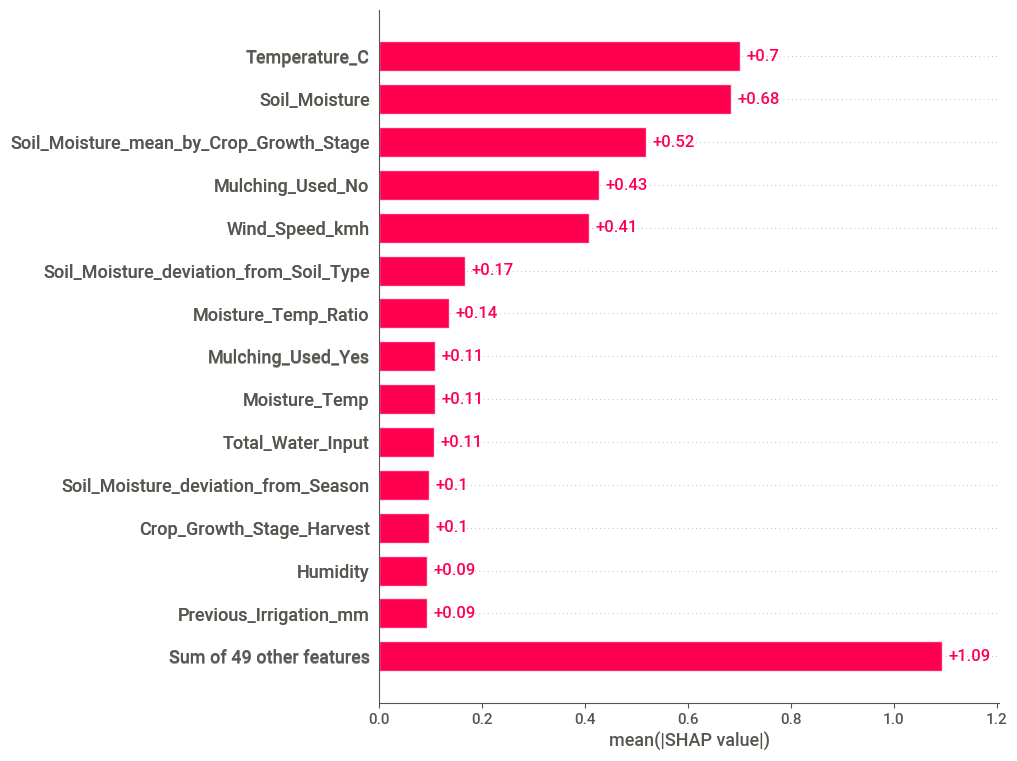

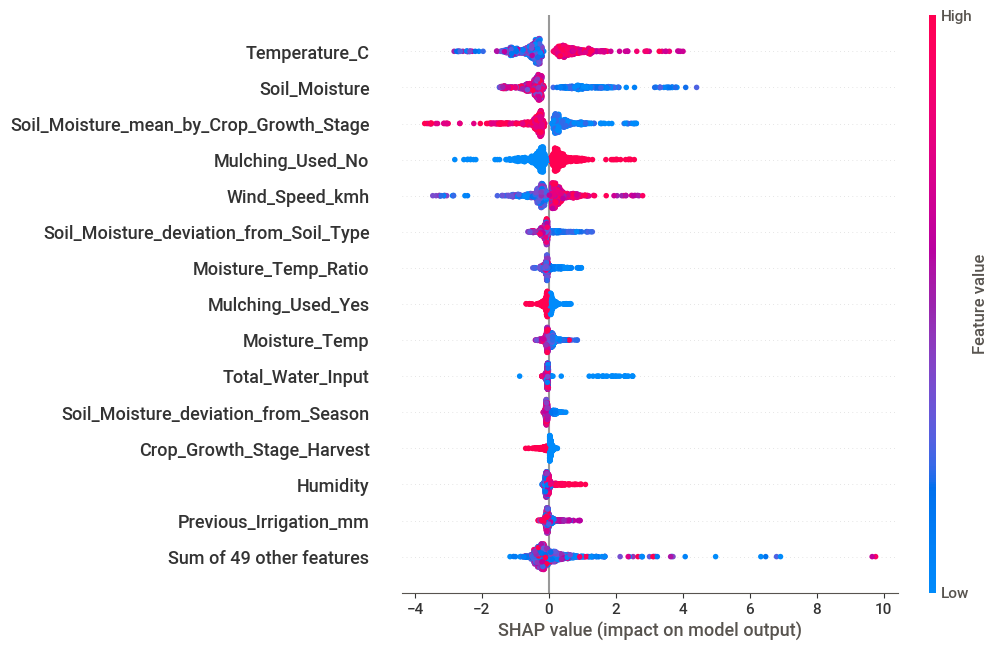

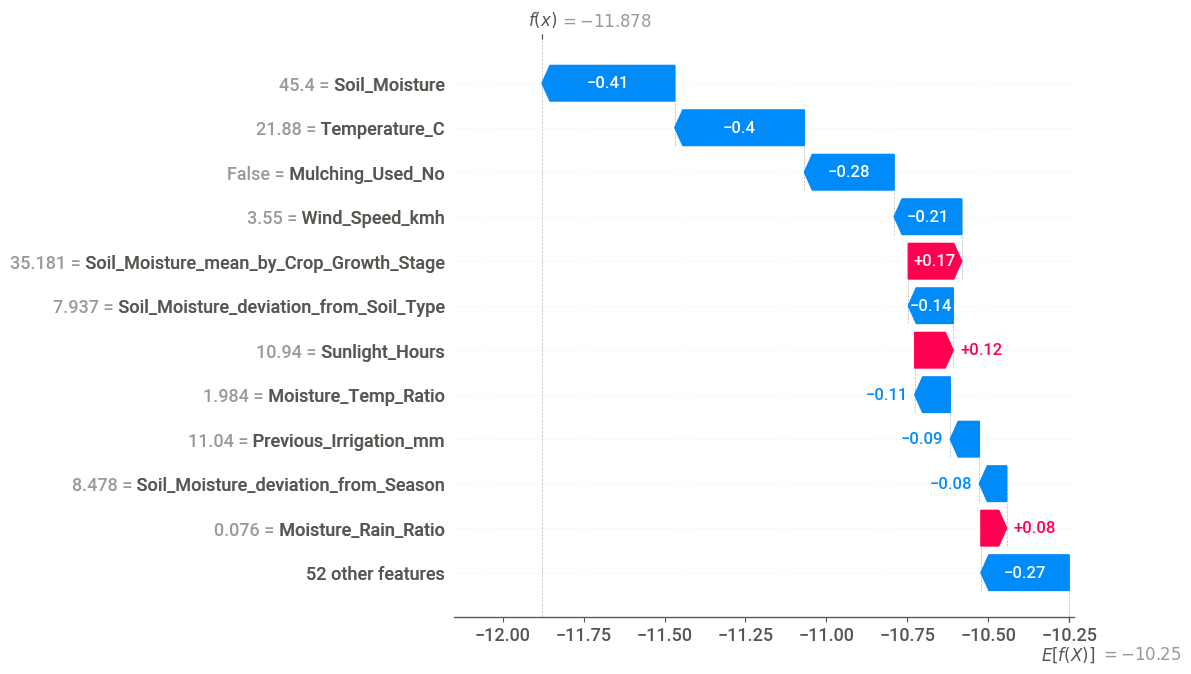

In [63]:
import numpy as np
import pandas as pd
import shap

from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split

TARGET = "Irrigation_Need"
ID_COL = "id"
RANDOM_STATE = 42

train_df = pd.read_csv("train.csv")


def add_shap_features(df):
    df = df.copy()

    df["Moisture_Temp"] = df["Soil_Moisture"] * df["Temperature_C"]
    df["Rain_Humidity"] = df["Rainfall_mm"] * df["Humidity"]
    df["Sun_Temp"] = df["Sunlight_Hours"] * df["Temperature_C"]
    df["Moisture_Rain_Ratio"] = df["Soil_Moisture"] / (df["Rainfall_mm"] + 1)
    df["Temp_Humidity_Ratio"] = df["Temperature_C"] / (df["Humidity"] + 1)
    df["pH_Deviation"] = (df["Soil_pH"] - 6.5).abs()
    df["Irrigation_Per_Hectare"] = df["Previous_Irrigation_mm"] / (df["Field_Area_hectare"] + 0.01)
    df["Rainfall_Per_Hectare"] = df["Rainfall_mm"] / (df["Field_Area_hectare"] + 0.01)
    df["Moisture_Temp_Ratio"] = df["Soil_Moisture"] / (df["Temperature_C"] + 1)
    df["Total_Water_Input"] = df["Rainfall_mm"] + df["Previous_Irrigation_mm"]
    df["Dryness_Index"] = (df["Temperature_C"] * df["Sunlight_Hours"]) / (df["Rainfall_mm"] + 1)
    df["Evaporative_Stress"] = (
        df["Temperature_C"] * df["Sunlight_Hours"] * df["Wind_Speed_kmh"]
    ) / (df["Humidity"] + 1)
    df["Soil_Health"] = (df["Organic_Carbon"] * df["Soil_Moisture"]) / (df["Electrical_Conductivity"] + 0.1)
    df["Moisture_Retention"] = df["Soil_Moisture"] * df["Organic_Carbon"]

    for group_col in ["Soil_Type", "Season", "Crop_Growth_Stage"]:
        mean_col = f"Soil_Moisture_mean_by_{group_col}"
        dev_col = f"Soil_Moisture_deviation_from_{group_col}"
        group_mean = df.groupby(group_col, observed=False)["Soil_Moisture"].transform("mean")
        df[mean_col] = group_mean
        df[dev_col] = df["Soil_Moisture"] - group_mean

    return df.replace([np.inf, -np.inf], np.nan)


SHAP_N = min(20000, len(train_df))
sample_idx, _ = train_test_split(
    np.arange(len(train_df)),
    train_size=SHAP_N,
    stratify=train_df[TARGET],
    random_state=RANDOM_STATE,
)

X_shap_raw = train_df.iloc[sample_idx].drop(columns=[ID_COL, TARGET]).reset_index(drop=True)
y_shap = train_df.iloc[sample_idx][TARGET].reset_index(drop=True)

X_shap = add_shap_features(X_shap_raw)

num_cols_shap = X_shap.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_shap = X_shap.select_dtypes(exclude=[np.number]).columns.tolist()

for col in num_cols_shap:
    X_shap[col] = X_shap[col].fillna(X_shap[col].median())

for col in cat_cols_shap:
    X_shap[col] = X_shap[col].fillna("Missing").astype(str)

X_shap_encoded = pd.get_dummies(X_shap, columns=cat_cols_shap, drop_first=False)

lgbm_shap_model = LGBMClassifier(
    objective="multiclass",
    n_estimators=200,
    learning_rate=0.08,
    num_leaves=48,
    min_child_samples=35,
    subsample=0.9,
    colsample_bytree=0.9,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    verbosity=-1,
    n_jobs=-1,
)
lgbm_shap_model.fit(X_shap_encoded, y_shap)

plot_sample = X_shap_encoded.sample(
    n=min(1000, len(X_shap_encoded)),
    random_state=RANDOM_STATE,
)

explainer = shap.TreeExplainer(lgbm_shap_model)
shap_values = explainer.shap_values(plot_sample)

high_class_index = list(lgbm_shap_model.classes_).index("High")

if isinstance(shap_values, list):
    high_values = shap_values[high_class_index]
    high_base_value = explainer.expected_value[high_class_index]
else:
    high_values = shap_values[:, :, high_class_index]
    high_base_value = explainer.expected_value[high_class_index]

high_explanation = shap.Explanation(
    values=high_values,
    base_values=np.repeat(high_base_value, len(plot_sample)),
    data=plot_sample.values,
    feature_names=plot_sample.columns.tolist(),
)

shap.plots.bar(high_explanation, max_display=15)
shap.plots.beeswarm(high_explanation, max_display=15)
shap.plots.waterfall(high_explanation[0], max_display=12)


# Approach

I started with separate models, then improved the workflow by adding stronger feature engineering and comparing the models with cross-validation. The main models I used were Gradient Boosting, LightGBM, and CatBoost. I added interaction and ratio features such as `Moisture_Temp`, `Rain_Humidity`, `Moisture_Rain_Ratio`, and `Temp_Humidity_Ratio`, then added more domain-based features such as `pH_Deviation`, rainfall and irrigation per hectare, moisture-temperature ratio, total water input, and grouped moisture deviation features.

The best individual leaderboard score came from LightGBM at about 0.96602. Gradient Boosting was close at about 0.96098 after feature engineering and tuning, and CatBoost scored about 0.95787. At the end, I compared the individual models with probability averaging, class adjustment for the rare `High` class, and a stacked logistic meta-model using the stored out-of-fold probabilities.




# Discussion

 
I implemented permuation testing and feature importance for LightGBM because it was consistently the strongest performing model. I tried feature engineering for the other models as well but there was only a slight model improvemnt. For my next steps,
I will use more feature engineering aroud soil moisture and its interaction with crop growth since those features had the highest impact on the model. For the approaches that I tried, my leaderboard score dropped to the 1900s and my highest performing model was the LightGBM at around 0.96602.

I was surprised that after training the individual models, the stacked ensemble did not take as long to run. I was happy to find out that the stacked ensemble was much easier to execute considering the data processing behind the scenes was much more
complex than the other models. I took out cross validation, and optuna as well. 
